In [1]:
import warnings, osmnx
warnings.filterwarnings("ignore")

# Spatial Data

Previously, we studied how surfaces can be converted to tables. In this lecture, we'll further explore how we move from pixels to polygons.


In [2]:
import pandas
import osmnx
import geopandas
import rioxarray
import xarray
import datashader
import contextily as cx
from shapely import geometry
import matplotlib.pyplot as plt

**Check your current working directory:**

In [3]:
import os

# Get the current working directory
current_directory = os.getcwd()

# Print the current working directory
print("Current working directory:", current_directory)

Current working directory: /home/wasif/sds/sds


#### Pixels to polygons

A second use case involves moving surfaces directly into geographic tables by
aggregating pixels into pre-specified geometries. For this illustration, we will
use the digital elevation model [(DEM)](../data/nasadem/build_nasadem_sd) surface containing elevation for the San Diego (US) region, and the set of [census tracts](../data/sandiego/sandiego_tracts_cleaning). For an example, we will investigate the average altitude of each neighborhood.

:question: What is a DEM?

A Digital Elevation Model (DEM) is a __digital representation__ of the Earth's surface topography or terrain. It consists of a grid of **elevation** values, where each cell in the grid represents the elevation of a specific point on the Earth's surface. DEMs are widely used in geographic information systems (GIS), remote sensing, and various applications related to terrain analysis, mapping, and modeling.

Let's start by reading the data. First, the elevation model:

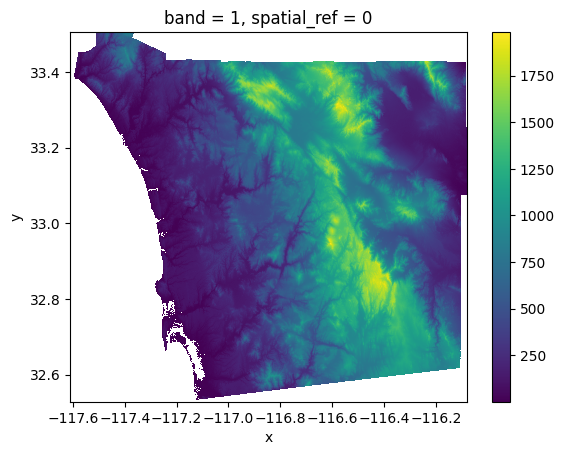

In [4]:
dem = rioxarray.open_rasterio("../Course-Datasets/nasadem_sd.tif").sel(
    band=1
)
dem.where(dem > 0).plot.imshow();

:question: Is this DEM an example of raster data or vector data?

Write your answer here.

:question: Find the CRS of the DEM.

In [5]:
# Your code here.
dem.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [ ]:
# Your code here

Now read the neighborhood geometries (tracts) from the census:

In [6]:
sd_tracts = geopandas.read_file(
    "../Course-Datasets/sandiego_tracts.gpkg"
)

:question: Add a column to `sd_tracts` containing areas of each tract

In [ ]:
# Your code here
sd_tracts["area"] = sd_tracts.geometry.area
sd_tracts.head()

,GEOID,median_age,total_pop,total_pop_white,tt_work,hh_total,hh_female,total_bachelor,median_hh_income,income_gini,...,county,tract,area_sqm,pct_rented,pct_hh_female,pct_bachelor,pct_white,sub_30,geometry,area
0,06073018300,37.1,2590.0,2375.0,1299.0,2590.0,137.0,0.0,62500.0,0.5355,...,073,018300,2.876449,0.373913,0.052896,0.000000,0.916988,False,"POLYGON ((-13069450.12 3922380.77, -13069175.2...",4.118911e+06
1,06073018601,41.2,5147.0,4069.0,1970.0,5147.0,562.0,24.0,88165.0,0.4265,...,073,018601,4.548797,0.205144,0.109190,0.004663,0.790558,False,"POLYGON ((-13067719.77 3922939.42, -13067631.0...",6.517618e+06
2,06073017601,54.4,5595.0,4925.0,1702.0,5595.0,442.0,34.0,110804.0,0.4985,...,073,017601,8.726275,0.279029,0.078999,0.006077,0.880250,False,"POLYGON ((-13058166.11 3907247.69, -13058140.0...",1.246229e+07
3,06073019301,42.3,7026.0,5625.0,3390.0,7026.0,638.0,46.0,100539.0,0.4003,...,073,019301,3.519743,0.196512,0.090806,0.006547,0.800598,False,"POLYGON ((-13056896.29 3925255.61, -13056868.7...",5.043952e+06
4,06073018700,21.8,40402.0,30455.0,24143.0,40402.0,2456.0,23.0,41709.0,0.3196,...,073,018700,559.150793,0.949887,0.060789,0.000569,0.753799,False,"POLYGON ((-13090788.51 3946435.43, -13090736.1...",8.036841e+08


:exclamation: What is the CRS of the geotable `sd_tracts`? Does it match with the CRS of the DEM?

In [9]:
# Your code here
sd_tracts.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Your answer here.

:question: Plot the geotable, with legend ON, ensuring that the fill colors of each tract vary in response to its area.

<Axes: >

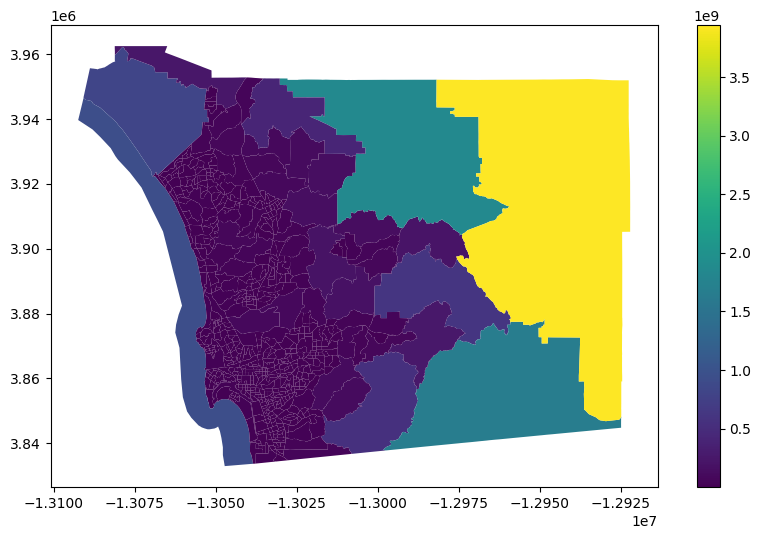

In [10]:
# Your code here.
sd_tracts.plot(column="area", legend=True, figsize=(10, 6))

### Zonal Statistics

**We want to compute the average altitude of each neighborhood**

There are several approaches to compute the average altitude of each neighborhood. We will use `rioxarray`to clip parts of the surface *within* a given set of geometries. By this, we mean that we will cut out the part of the raster that falls within each geometry, and then we can summarize the values in that sub-raster. This is sometimes called computing a "zonal statistic" from a raster, where the "zone" is the geometry.

Since this is somewhat complicated, we will start with a single polygon. For the illustration, we will use the largest one, located on the eastern side of San Diego. We can find the ID of the polygon with:

In [13]:
largest_tract_id = sd_tracts.query(
    f"area == {sd_tracts['area'].max()}"
).index[0]

largest_tract_id

627

And then pull out the polygon itself for the illustration:

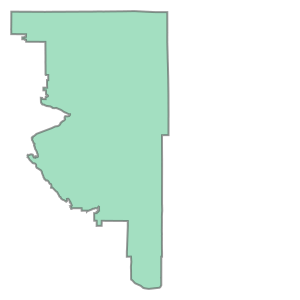

In [16]:
largest_tract = sd_tracts.loc[largest_tract_id, "geometry"]
largest_tract

Clipping the section of the surface that is within the polygon in the DEM can be achieved with the `rioxarray` extension to clip surfaces based on geometries:

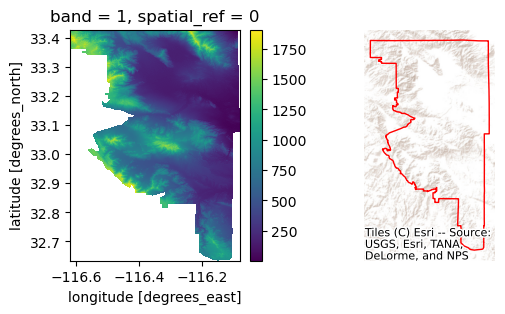

In [52]:
# Clip elevation for largest tract
dem_clip = dem.rio.clip(
    [largest_tract.__geo_interface__], crs=sd_tracts.crs
)

# Set up figure to display against polygon shape
f, axs = plt.subplots(1, 2, figsize=(6, 3))
# Display elevation of largest tract
dem_clip.where(dem_clip > 0).plot(ax=axs[0], add_colorbar=True)

# Display largest tract polygon
sd_tracts.loc[[largest_tract_id]].plot(
    ax=axs[1], edgecolor="red", facecolor="none"
)
axs[1].set_axis_off()
# Add basemap
cx.add_basemap(
    axs[1], crs=sd_tracts.crs, source=cx.providers.Esri.WorldTerrain
);

:exclamation: If the two CRSs were different, how did the clipping work?

Once we have elevation measurements for all the pixels within the tract, the average one can be calculated with `mean()`:

In [53]:
dem_clip.where(dem_clip > 0).mean()

<xarray.DataArray ()> Size: 4B
array(585.11346, dtype=float32)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

Now, to scale this to the entire geo-table, there are several approaches. Each has its benefits and disadvantages. We opt for applying the method above to each row of the table. We define an auxiliary function that takes a row containing one of our tracts and returns its elevation:

In [54]:
def get_mean_elevation(row, dem):
    # Extract geometry object
    geom = row["geometry"].__geo_interface__
    # Clip the surface to extract pixels within `geom`
    section = dem.rio.clip([geom], crs=sd_tracts.crs)
    # Calculate mean elevation
    elevation = float(section.where(section > 0).mean())
    return elevation

Applied to the same tract, it returns the same average elevation:

In [ ]:
get_mean_elevation(sd_tracts.loc[largest_tract_id, :], dem)

585.1134643554688

This method can then be run on each polygon in our series using the `apply()` method:

In [ ]:
elevations = sd_tracts.head().apply(
    get_mean_elevation, dem=dem, axis=1
)
elevations

0      7.144268
1     35.648491
2     53.711388
3     91.358780
4    187.312027
dtype: float64

This simple approach illustrates the main idea well: find the cells that pertain to a given geometry and summarize their values in some manner. This can be done with any kind of geometry. Further, this simple method plays well with `xarray` surface structures and is scalable in that it is not too involved to run in parallel and distributed form using libraries like `dask`. Further, it can be extended using arbitrary Python functions, so it is simple to extend.

However, this approach can be quite slow in big data. A more efficient
alternative for our example uses the `rasterstats` library. This is a
purpose-built library to construct so-called "zonal statistics" from
surfaces. Here, the "zones" are the polygons and the "surface" is our
`DataArray`. Generally, this library will be faster than the simpler approach
used above, but it may be more difficult to extend or adapt:

In [17]:
from rasterstats import zonal_stats

elevations2 = zonal_stats(
    sd_tracts.to_crs(dem.rio.crs),  # Geotable with zones
    "../Course-Datasets/nasadem_sd.tif",  # Path to surface file
)
elevations2 = pandas.DataFrame(elevations2)

In [18]:
elevations2.head()

,min,max,mean,count
0,-12.0,18.0,3.538397,3594
1,-2.0,94.0,35.616395,5709
2,-5.0,121.0,48.742630,10922
3,31.0,149.0,91.358777,4415
4,-32.0,965.0,184.284941,701973


To visualize these results, we can make an elevation map:

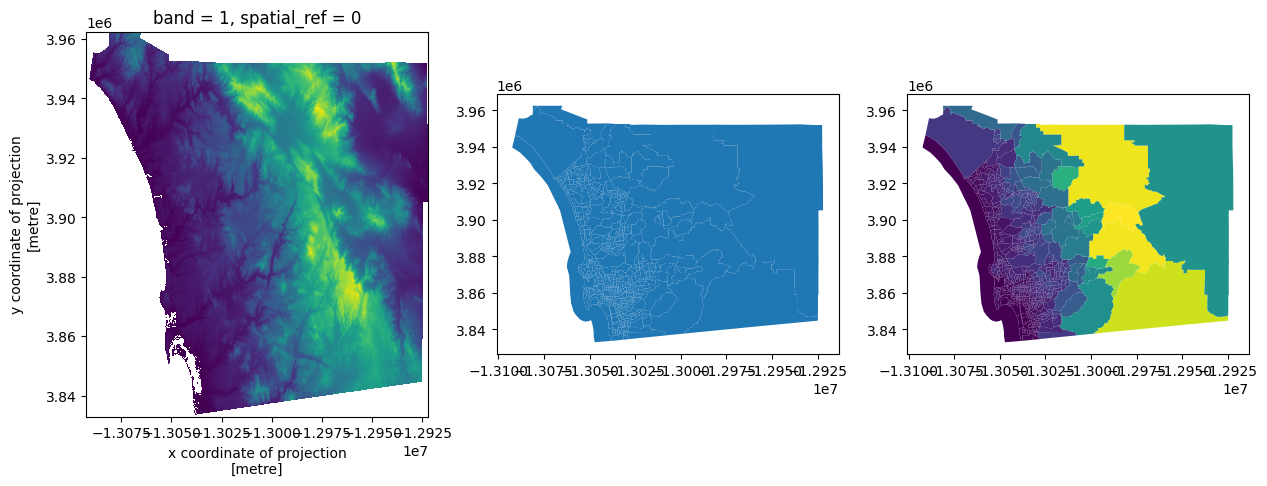

In [ ]:
# Set up figure
f, axs = plt.subplots(1, 3, figsize=(15, 5))

# Plot elevation surface
dem.where(  # Keep only pixels above sea level
    dem
    > 0
    # Reproject to CRS of tracts
).rio.reproject(
    sd_tracts.crs
    # Render surface
).plot.imshow(
    ax=axs[0], add_colorbar=False
)

# Plot tract geography
sd_tracts.plot(ax=axs[1])

# Plot elevation on tract geography
sd_tracts.assign(  # Append elevation values to tracts
    elevation=elevations2["mean"]
).plot(  # Plot elevation choropleth
    "elevation", ax=axs[2]
);

### Tables as surfaces

The case for converting tables into surfaces is perhaps less controversial than that for turning surfaces into tables. This is an approach we can take in cases where we are interested in the *overall* distribution of objects (usually points) and we have so many that it is not only technically more efficient to represent them as a surface, but conceptually it is also easier to think about the points as uneven measurements from a continuous field. To illustrate this approach, we will use the dataset of [Tokyo photographs](../data/tokyo/tokyo_cleaning) we loaded above into `gt_points`.

From a purely technical perspective, for datasets with too many points, representing every point in the data on a screen can be seriously overcrowded:

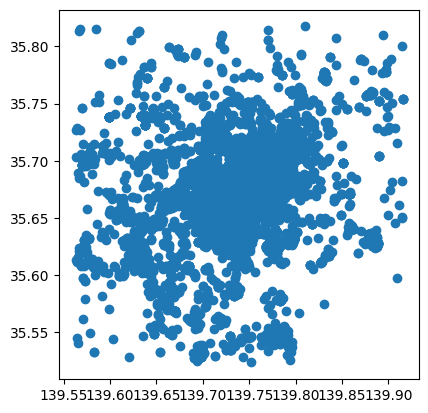

In [317]:
gt_points.plot();

In this figure, it is hard to tell anything about the density of points in the center of the image due to *overplotting*: while points *theoretically* have no width, they *must* have some dimension in order for us to see them! Therefore, point *markers* often plot on top of one another, obscuring the true pattern and density in dense areas. Converting the dataset from a geo-table into a surface involves laying out a grid and counting how many points fall within each cell. In one sense, this is the reverse operation to what we saw when computing zonal statistics in the previous section: instead of aggregating cells into objects, we aggregate objects into cells. Both operations, however, involve aggregation that reduces the amount of information present in order to make the (new) data more manageable. 

In Python, we can rely on the `datashader` library, which does all the computation in a very efficient way. This process involves two main steps. First, we set up the grid (or canvas, `cvs`) into which we want to aggregate points:

In [318]:
cvs = datashader.Canvas(plot_width=60, plot_height=60)

Then we "transfer" the points into the grid:

In [319]:
grid = cvs.points(gt_points, x="longitude", y="latitude")

The resulting `grid` is a standard `DataArray` object that we can then manipulate as we have seen before. When plotted below, the amount of detail that the resampled data allows for is much greater than when the points were visualized alone. This is shown in Figure 14. 

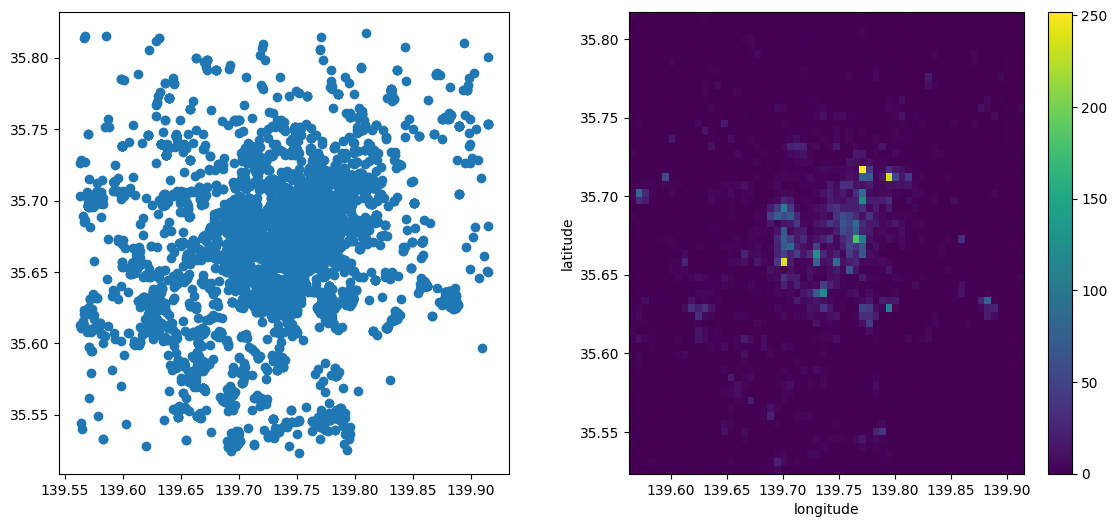

In [320]:
f, axs = plt.subplots(1, 2, figsize=(14, 6))
gt_points.plot(ax=axs[0])
grid.plot(ax=axs[1]);

### Networks as graphs *and* tables

In the previous chapter, we saw networks as data structures that store *connections* between objects. We also discussed how this broad definition includes many interpretations that focus on different aspects of the networks. While spatial analytics may use graphs to record the topology of a table of objects such as polygons, transport applications may treat the network representation of the street layout as a set of objects itself, in this case lines. In this final section we show how one can flip back and forth between one representation and another, to take advantage of different aspects.

We start with the `graph` object from the [previous section](#Spatial-graphs). Remember this captures the street layout around Yoyogi park in Tokyo. We have seen how, stored under this data structure, it is easy to query which node is connected to which, and which ones are at the end of a given edge. 

However, in some cases, we may want to convert the graph into a structure that allows us to operate on each component of the network independently. For example, we may want to map streets, calculate segment lengths, or draw buffers around each intersection. These are all operations that do not require topological information, that are standard for geo-tables, and that are irrelevant to the graph structure. In this context, it makes sense to convert our `graph` to two geo-tables, one for intersections (graph nodes) and one for street segments (graph edges). In `osmnx`, we can do that with the built-in converter:

In [321]:
gt_intersections, gt_lines = osmnx.graph_to_gdfs(graph)

Now each of the resulting geo-tables is a collection of geographic objects:

In [322]:
gt_intersections.head()

,y,x,street_count,highway,geometry
osmid,,,,,
886196069,35.670087,139.694333,3,NaN,POINT (139.69433 35.67009)
886196073,35.669691,139.699549,3,NaN,POINT (139.69955 35.66969)
886196100,35.669442,139.699708,3,NaN,POINT (139.69971 35.66944)
886196106,35.670422,139.698564,4,NaN,POINT (139.69856 35.67042)
886196117,35.671256,139.697470,3,NaN,POINT (139.69747 35.67126)


In [323]:
gt_lines.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 305 entries, (886196069, 1520546857, 0) to (12466105514, 10574987647, 0)
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   osmid     305 non-null    object  
 1   highway   305 non-null    object  
 2   oneway    305 non-null    bool    
 3   reversed  305 non-null    object  
 4   length    305 non-null    float64 
 5   geometry  305 non-null    geometry
 6   lanes     2 non-null      object  
 7   maxspeed  2 non-null      object  
 8   name      11 non-null     object  
 9   ref       2 non-null      object  
 10  bridge    6 non-null      object  
 11  access    2 non-null      object  
dtypes: bool(1), float64(1), geometry(1), object(9)
memory usage: 37.6+ KB


If we were in the opposite situation, where we had a set of street segments and their intersections in geo-table form, we can generate the graph representation with the `graph_from_gdfs` sister method:

In [324]:
new_graph = osmnx.graph_from_gdfs(gt_intersections, gt_lines)

The resulting object will behave in the same way as our original `graph`.

## Conclusion

In conclusion, this chapter provides an overview of the mappings between data models, presented in Chapter 2, and data structures that are common in Python. Beyond the data structures discussed here, the Python ecosystem is vast, deep, and ever-changing. Part of this is the ease with which you can create your own representations to express different aspects of a problem at hand. However, by focusing on our shared representations and the interfaces between these representations, you can generally conduct any analysis you need. By creating unique, bespoke representations, your analysis might be more efficient, but you can also inadvertently isolate it from other developers and render useful tools inoperable. Therefore, a solid understanding of the basic data structures (the `GeoDataFrame`, `DataArray`, and `Graph`) will be sufficient to support nearly any analysis you need to conduct. 

## Questions

1. One way to convert from `Multi-`type geometries into many individual geometries is using the `explode()` method of a GeoDataFrame. Using the `explode()` method, can you find out how many islands are in Indonesia?

2. Using `osmnx`, are you able to extract the street graph for your hometown?

3. As you have seen with the `osmnx.graph_to_gdfs()` method, it is possible to convert a graph into the constituent nodes and edges. Graphs have many other kinds of non-geographical representations. Many of these are provided in `networkx` methods that start with `to_`. How many representations of graphs are currently supported?

4. Using `networkx.to_edgelist()`, what "extra" information does `osmnx` include when building the dataframe for edges?

5. Instead of computing the average elevation for each neighborhood in San Diego, can you answer the following queries?
  - What neighborhood (or neighborhoods) have the *the highest average elevation*?
  - What neighborhood (or neighborhoods) have *the highest point single point*?
  - Can you find the neighborhood (or neighborhoods) with *the largest elevation change*?

[^package-v-function]: We will generally use two curved brackets (such as `method_name()`) to denote a *function*, and will omit them (such as `package`) when referring to an object or package.]
[^xarray-query]: Although, if all you want to do is this type of query, `xarray` is well equipped for this kind of task too.